# 2-D CARMApy

CARMApy also has a 2-D mode, as described in Powell and Zhang (2024).  It works by advecting the entire cloud column at a constant longitudinal wind speed along the equator while allowing the temperature structure to vary by longitude.  To tell CARMApy that the model is a 2-D one, set the flag `is_2d=True` when calling the `carmapy.Carma()` constructor.

In [1]:
import carmapy
from matplotlib import pyplot as plt
import numpy as np

carma = carmapy.Carma("2d_carmapy", is_2d=True)

# carma.set_stepping(dt=5000, output_gap=1000, n_tstep=250000)
carma.set_stepping(dt=5000, output_gap=249999, n_tstep=250000)

Note that for this model it runs for far longer than a 1-D model as it takes longer to converge (note that this model is for demonstation purposes only—it should not be necessarily considered to be converged).  

CARMApy also provides sample atmospheric profiles for an example 2-D CARMApy run.  These profiles are taken from GCM simulations of sub-neptunes in Steinrueck et al. (2024)

In [2]:
P_levs, T_levs, kzz_levs, longitudes = carmapy.example.example_2d_levels()

carma.add_P(P_levs)
carma.add_T(T_levs)
carma.add_kzz(kzz_levs)

Note that unlike in the 1-D model, `T_levs` is a 2-D array of shape `(NZ, NLONGITUDE)`

We can now set the physical parameters of the atmosphere.  The surface gravity, mean molecular weight, and metallicity are set as before.  We also now must set the average logitudinal wind velocity `velocity_avg` and the radius of the planet `r_planet`.  By default all of these quantities are in cgs units but we can use the `use_jovian_radius=True` flag to instead specify the planetary radius in Jovian radii

In [3]:
carma.set_physical_params(
    surface_grav = 1060,
    wt_mol=28.7,
    log_metallicity=3.5,
    velocity_avg=1e5,
    r_planet=0.25,
    use_jovian_radius=True
)
carma.set_atmospheric_parameters_from_defaults("Pure H2")

Having specified the physical parameters and the non-z atmospheric profile, we can now tell CARMApy to calculate the z coordinate profile of the atmosphere.

WARNING: Unlike in a 1-D run, the z-coordinate does not correspond to a cartesian altitude, it instead is a log pressure coordinate which is equal to the longitudinally averaged scale height at the base of the atmosphere multiplied by the absolute value of the log ratio of the pressure coordinate to the pressure at the base of the atmosphere.  It is reccomended to just use `carma.calculate_z()` for this calculation

In [4]:
carma.calculate_z()

We will now add the cloud groups to our model.  As this is a cooler model than our example 1-D model, we will be adding KCl as a homogeneously nucleating species and ZnS as a species that can heterogeneously nucleate on KCl.  Note that `populate_abundances_at_cloud_base()` determines the cloud base from a longitudinally averaged P-T profile

In [5]:
carma.add_hom_group("KCl", 1e-8)
carma.add_het_group("ZnS", "KCl", 1e-8 * 2**(1/3))
carmapy.chemistry.populate_abundances_at_cloud_base(carma)

We can now run our model.  This run should take 20-60 min depending on your computer (The `carma.run()` command is commented out as it takes too long to run when compiling the documentation—if you are following along you should uncomment that piece of code)

In [6]:
# carma.run()

For 2-D CARMApy in particular it is reccomended to restart a longer run but with dense output frequency to ensure that you can get output data for the entire planet at a similar time.  Setting the `carma.restart=1` flag tells the model to continue from the last saved model state instead of starting from a blank slate atmosphere again

In [ ]:
carma.restart=1
carma.set_stepping(dt=800, output_gap=1, n_tstep=3000)
carma.run(suppress_output=True)

 

 Create CARMA Object ...

  

   Add Group(s) ...

  

 Add Pure KCl...

 Add ZnS on KCl...

  

   Add Element(s) ...

  

 Add Pure KCl...

 Add ZnS Mantle...

 Add KCl Core (ZnS)...

  

   Add Solute(s) ...

  

 Add H2SO4 Solute ...

  

   Add Gas(es) ...

  

 Add H2O Vapor ...

           2

 Add KCl Vapor ...

          19

 Add ZnS Vapor ...

          19

   Add Nucleation ...

   Add Growth ...

   Add Coagulation ...

  

 Initialize CARMA ...



Particle grid structure (setupbins):

NGROUP :       2

NELEM  :       3

NBIN   :      80

Massmin:     8.327E-24   3.385E-23

Mrat   :          2.00        2.00

nelemg :       1     2

itype  :       2     2     3

ienconc:       1     2

igelem :       1     2     2

ncore  :       0     1

  

 Nucleation mapping arrays (setupnuc):

  

 Elements mapping:

 ielem,nnucelem=           1           1

 jfrom,inucelem=             1           1

 ielem,nnucelem=           2           1

 jfrom,inucelem=             1           

As before, we can read our results with `carmapy.read_results()`

In [18]:
carma.read_results(read_diag=True)

Plotting our results is very similar to in 1-D CARMApy.  Because it is often desired to plot results as a function of longitude instead of timestep, for 2-D runs CARMApy provides the function `carma.results.longitude_map()`. This function takes in a 3-D array of shape `(NZ, NBIN, NT)` and transforms it to an array of shape `(NZ, NBIN, NLONGITUDE)` where each longitude bin in the average of all timesteps corresponding to that longitude.  This function is designed to work on the `"numden"` array as well as any of the microphysical rates arrays

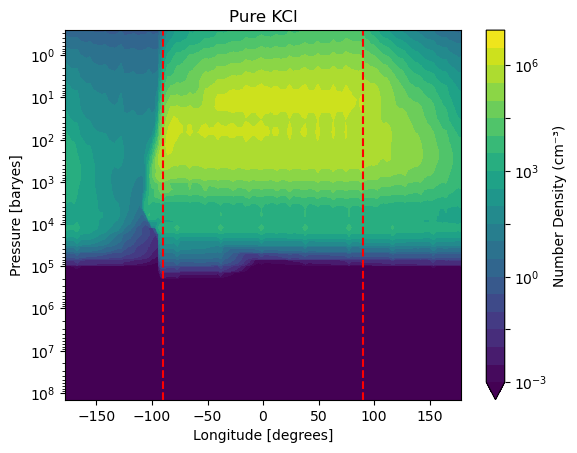

In [19]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

species = "Pure KCl"

t_step = -1

density = np.nansum(carma.results.longitude_map(carma.results.clouds[species]["numden"]), axis=1)

max_den = np.nanmax(density)

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(longitudes,
             carma.results.P,
             density + 1e-100,
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min")

plt.plot(np.ones(carma.results.P.shape) * -90, carma.results.P, 'r--')
plt.plot(np.ones(carma.results.P.shape) * 90, carma.results.P, 'r--')

plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Longitude [degrees]")


plt.colorbar(label="Number Density (cm⁻³)")
plt.title(species)
plt.show()

As you can see, most of the cloud formation occurs on the dayside of the planet (between the two dashed-red lines).  Note that the periodic beating with longitude is unlikely to be physical—it can be reduced by increasing the number of timesteps averaged over.

As before, we can also make this plot for Zns on KCl clouds

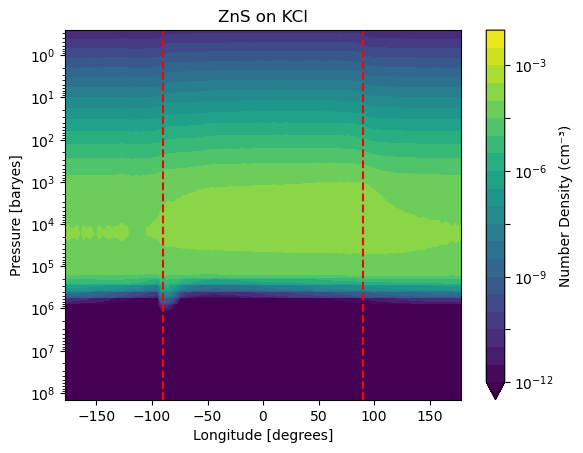

In [10]:
species = "ZnS on KCl"

t_step = -1

density = np.nansum(carma.results.longitude_map(carma.results.clouds[species]["numden"]), axis=1)

max_den = np.nanmax(density)

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(longitudes,
             carma.results.P,
             density + 1e-100,
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min")

plt.plot(np.ones(carma.results.P.shape) * -90, carma.results.P, 'r--')
plt.plot(np.ones(carma.results.P.shape) * 90, carma.results.P, 'r--')

plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Longitude [degrees]")


plt.colorbar(label="Number Density (cm⁻³)")
plt.title(species)
plt.show()

As mentioned before, the `longitude_map()` function also works for microphysical rates

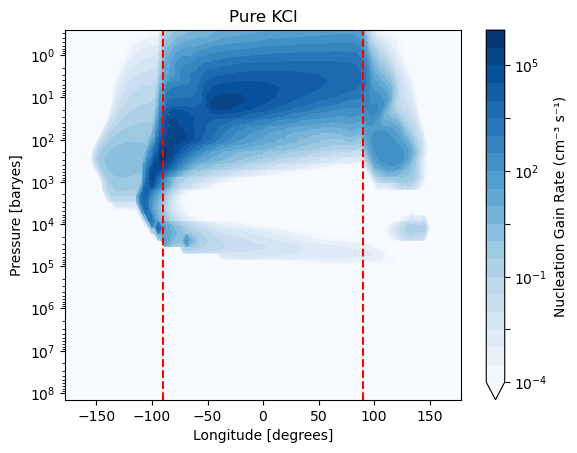

In [11]:
species = "Pure KCl"

t_step = -1

density = np.nansum(carma.results.longitude_map(carma.results.clouds[species]["grow_gain_rate"]), axis=1)

max_den = np.nanmax(density)

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(longitudes,
             carma.results.P,
             density + 1e-100,
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min",
             cmap="Blues")

plt.plot(np.ones(carma.results.P.shape) * -90, carma.results.P, 'r--')
plt.plot(np.ones(carma.results.P.shape) * 90, carma.results.P, 'r--')

plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Longitude [degrees]")


plt.colorbar(label="Nucleation Gain Rate (cm⁻³ s⁻¹)")
plt.title(species)
plt.show()